# 2. Finite time: switching on the drive — SM Fig. S1

At finite time every diagram contributes, not only those closing on $r_{00}$: a diagram with outgoing label $O_{pq}$ closes on the initial-state component $r_{qp}$ with weight $\mathrm{Tr}[O_{pq}\rho_0]$. The cavity starts empty, which in the displaced frame is a coherent state of amplitude $-\alpha$, so every state label contributes. The finite-time rules are evaluated in Laplace space (`engines/finite_time.py`), $U=0.1\kappa$.

**Part A** runs the calculation; **Part B** regenerates Fig. S1 with `make_figures.py finite` (~1 min).

In [1]:
from common import *
FAST = True      # True: reduced orders and cutoffs, minutes.  False: the orders and cutoffs of the paper (see the runtime note)
print("repository:", os.path.basename(CODE), "| FAST =", FAST, "| paper sources:", "found" if PAPER else "not present (Tables V and SI from notebooks/paper_reference/)")

repository: gh_staging | FAST = True | paper sources: not present (Tables V and SI from notebooks/paper_reference/)


## Part A — the calculation

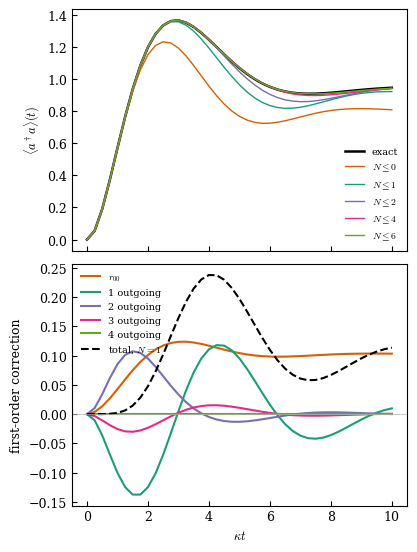

max |error| through N=6: 3.96e-03


In [2]:
from finite_time import kerr_finite_time, kerr_exact_time
kappa, Dc, eta = 1.0, -1.0, 1.0
U = 0.1; ts = np.linspace(0,10,41 if FAST else 101); Nft = 6 if FAST else 8
ser, parts = kerr_finite_time(kappa, Dc, eta, U, ts, Nft, lambda a_,ad_: mul(ad_,a_), by_degree=True)
ext = kerr_exact_time(kappa, Dc, eta, U, ts); ps = np.cumsum(ser.real, axis=1)
fig,(ax1,ax2) = plt.subplots(2,1,figsize=(4.2,5.6),sharex=True)
ax1.plot(ts, ext,'k-',lw=1.8,label='exact')
for c,N in zip(COL,[0,1,2,4,Nft]): ax1.plot(ts, ps[:,N], color=c, lw=1, label=f'$N\\leq{N}$')
ax1.set_ylabel(r'$\langle a^\dagger a\rangle(t)$'); ax1.legend(fontsize=7)
for c,d in zip(COL,range(5)):
    if d in parts[1]: ax2.plot(ts, parts[1][d].real, color=c, label=('$r_{00}$' if d==0 else f'{d} outgoing'))
ax2.plot(ts, ser[:,1].real,'k--',label='total, $N=1$'); ax2.axhline(0,color='0.7',lw=0.5)
ax2.set_xlabel(r'$\kappa t$'); ax2.set_ylabel('first-order correction'); ax2.legend(fontsize=7)
fig.tight_layout(); plt.show()
print(f"max |error| through N={Nft}: {np.max(np.abs(ps[:,Nft]-ext)):.2e}")

## Part B — Fig. S1 of the paper

$ (cd code/engines; python3 make_figures.py finite)   [90.9 s, exit 0]
  0.9446743472614095
 ]
}


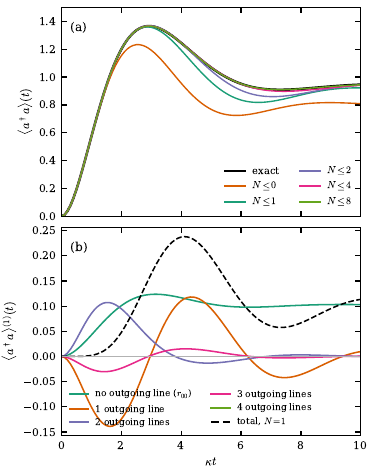

max error over t in [0,10]: N<=8 1.5e-03, N<=4 1.3e-02
at kappa t = 5: exact 1.0687; partial sums N=0,1,2,4,8: 0.7681, 0.9648, 1.0461, 1.0716, 1.0686


In [3]:
run("python3 make_figures.py finite", "engines", timeout=1800)
paper_figure("engines/fig_kerr_finite_time.pdf", width=420)
n = J("engines", "numbers.json")
print(f"max error over t in [0,10]: N<=8 {n['finite_maxerr_N8']:.1e}, N<=4 {n['finite_maxerr_N4']:.1e}")
print(f"at kappa t = 5: exact {n['finite_t5'][0]:.4f}; partial sums N=0,1,2,4,8: " + ", ".join(f"{x:.4f}" for x in n['finite_t5'][1:]))